In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as si
import scipy.optimize as optimize

In [4]:
df = pd.read_csv('VOO option chain.csv')

In [5]:
df.head()

,Trade Date,Strike,Expiry Date,Call/Put,Last Trade Price,Bid Price,Ask Price,Bid Implied Volatility,Ask Implied Volatility,Open Interest,Volume,Delta,Gamma,Vega,Theta,Rho
0,2023-07-03,180,2023-07-21,c,231.36,230.74,233.27,0.0,2.0808,0,0,1.0,0.0,0.0,-0.0268,0.0892
1,2023-07-03,185,2023-07-21,c,223.33,222.30,224.00,0.0,1.7034,0,0,1.0,0.0,0.0,-0.0276,0.0917
2,2023-07-03,190,2023-07-21,c,221.25,219.39,222.93,0.0,1.9136,0,0,1.0,0.0,0.0,-0.0283,0.0941
3,2023-07-03,195,2023-07-21,c,211.94,211.08,212.77,0.0,1.6569,0,0,1.0,0.0,0.0,-0.0291,0.0966
4,2023-07-03,200,2023-07-21,c,211.50,210.41,212.24,0.0,1.5689,0,0,1.0,0.0,0.0,-0.0298,0.0991


In [6]:
print(df['Expiry Date'].nunique())
print(df['Strike'].nunique())

8
98


In [7]:
df_c = df[df['Call/Put'] == 'c']

In [8]:
common_strikes = (df_c.groupby('Strike')['Expiry Date']
                  .nunique() # makes into a series of strikes with associated num of unique expiry dates
                  .loc[lambda x: x == df_c['Expiry Date'].nunique()]
                  .index)

print(common_strikes.tolist())

[255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470]


In [9]:
df2 = df_c[df_c['Strike'].isin(common_strikes)]

In [10]:
df2.head()

,Trade Date,Strike,Expiry Date,Call/Put,Last Trade Price,Bid Price,Ask Price,Bid Implied Volatility,Ask Implied Volatility,Open Interest,Volume,Delta,Gamma,Vega,Theta,Rho
15,2023-07-03,255,2023-07-21,c,151.98,151.17,152.96,0.0,1.1380,0,0,1.0,0.0,0.0,-0.0380,0.1264
16,2023-07-03,260,2023-07-21,c,148.53,148.30,148.80,0.0,0.9014,0,0,1.0,0.0,0.0,-0.0388,0.1288
17,2023-07-03,265,2023-07-21,c,141.88,141.63,142.12,0.0,0.8613,0,0,1.0,0.0,0.0,-0.0395,0.1313
18,2023-07-03,270,2023-07-21,c,138.56,138.30,138.80,0.0,0.8220,0,0,1.0,0.0,0.0,-0.0403,0.1338
19,2023-07-03,275,2023-07-21,c,132.01,131.74,132.24,0.0,0.7834,0,0,1.0,0.0,0.0,-0.0410,0.1363


In [11]:
wanted_strikes  = pd.Series(np.arange(260, 340, 10))
print(wanted_strikes)

0    260
1    270
2    280
3    290
4    300
5    310
6    320
7    330
dtype: int64


In [12]:
df3 = df2[(df2['Strike'].isin(wanted_strikes)) & (df2['Call/Put'] == 'c')].copy()

In [13]:
df3['Expiry Date'] = pd.to_datetime(df['Expiry Date'])
df3['Trade Date'] = pd.to_datetime(df['Trade Date'])

df3['Days to Expiry'] = df3['Expiry Date'] - df3['Trade Date']
df3['TTM'] = ((df3['Expiry Date'] - df3['Trade Date'])/ pd.Timedelta(days=1))/365

In [14]:
df3.drop(columns = ['Call/Put', 'Bid Implied Volatility', 'Ask Implied Volatility', 'Open Interest', 
                    'Volume', 'Delta', 'Gamma', 'Vega', 'Theta', 'Rho'], inplace = True)

In [15]:
df3['Price'] = (df3['Ask Price'] + df3['Bid Price'])/2 # Midprice is used as an approximation of the market price

In [16]:
df3['Days to Expiry'].unique() # make new column of treasury rates r for months 1, 3, 6, 1 year, 2 year

<TimedeltaArray>
[ '18 days',  '46 days',  '74 days', '109 days', '165 days', '200 days',
 '354 days', '564 days']
Length: 8, dtype: timedelta64[ns]

### Make new column of treasury rates r for months 1, 3, 6, 1 year, 2 year

In [17]:
df3['r'] = np.nan

rates = { # reference table
    30: 0.0527,   # 1 month
    91: 0.0540,   # 3 months
    182: 0.0553,  # 6 months
    365: 0.0543,  # 1 year
    730: 0.0494   # 2 years
}

df3.loc[df3['Days to Expiry'] == '18 Days', 'r'] = 0.0527
df3.loc[df3['Days to Expiry'] == '46 Days', 'r'] = 0.0527
df3.loc[df3['Days to Expiry'] == '74 Days', 'r'] = 0.0540
df3.loc[df3['Days to Expiry'] == '109 Days', 'r'] = 0.0540
df3.loc[df3['Days to Expiry'] == '165 Days', 'r'] = 0.0553
df3.loc[df3['Days to Expiry'] == '200 Days', 'r'] = 0.0553
df3.loc[df3['Days to Expiry'] == '354 Days', 'r'] = 0.0543
df3.loc[df3['Days to Expiry'] == '564 Days', 'r'] = 0.0494

In [18]:
df3

,Trade Date,Strike,Expiry Date,Last Trade Price,Bid Price,Ask Price,Days to Expiry,TTM,Price,r
16,2023-07-03,260,2023-07-21,148.53,148.30,148.8,18 days,0.049315,148.550,0.0527
18,2023-07-03,270,2023-07-21,138.56,138.30,138.8,18 days,0.049315,138.550,0.0527
20,2023-07-03,280,2023-07-21,128.59,128.30,128.9,18 days,0.049315,128.600,0.0527
22,2023-07-03,290,2023-07-21,118.62,118.40,118.9,18 days,0.049315,118.650,0.0527
24,2023-07-03,300,2023-07-21,108.64,108.40,108.9,18 days,0.049315,108.650,0.0527
...,...,...,...,...,...,...,...,...,...,...
977,2023-07-03,290,2025-01-17,138.21,136.90,139.5,564 days,1.545205,138.200,0.0494
979,2023-07-03,300,2025-01-17,129.71,128.30,131.0,564 days,1.545205,129.650,0.0494
981,2023-07-03,310,2025-01-17,121.18,119.80,122.2,564 days,1.545205,121.000,0.0494
983,2023-07-03,320,2025-01-17,112.87,111.40,113.9,564 days,1.545205,112.650,0.0494


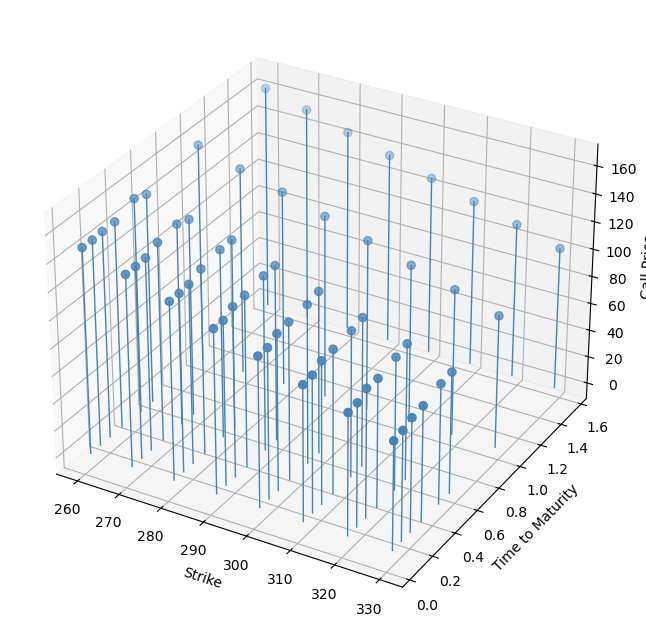

In [34]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Example data
K = df3['Strike'].copy()          # shape (N,)
T = df3['TTM'].copy()       # shape (N,)
price = df3['Price'].copy()   # model price - market price

# Draw vertical stems
for x, y, z in zip(K, T, price):
    ax.plot([x, x], [y, y], [0, z], color='steelblue', linewidth=1)

# Draw points
ax.scatter(K, T, price,
           color='steelblue',
           s=35)

ax.set_xlabel("Strike")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Call Price")

plt.savefig('option price grid.png')
plt.show()

In [33]:
print(K)
print(price)

16     260
18     270
20     280
22     290
24     300
      ... 
977    290
979    300
981    310
983    320
985    330
Name: Strike, Length: 64, dtype: int64
16     148.550
18     138.550
20     128.600
22     118.650
24     108.650
        ...   
977    138.200
979    129.650
981    121.000
983    112.650
985    103.755
Name: Price, Length: 64, dtype: float64


In [21]:
# Open: $406.94 High: $408.06 Low: $406.94 for 2023-07-03
S = (408.06 + 406.94)/2

In [22]:
def black_scholes_price(S, K, T, r, q, sigma, option_type="call"):
  # Calculate Black-Scholes theoretical option value
  d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)

  if option_type == "call":
    price = S * np.exp(-q*T) * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
  else:
    price = K * np.exp(-r * T) * si.norm.cdf(-d2) - S * np.exp(-q*T) * si.norm.cdf(-d1)

  return price


def implied_volatility(market_price, S, K, T, r, q, option_type="call"):
  # Define objective function: difference between model price and market price
  def objective_function(sigma):
    return (
        black_scholes_price(S, K, T, r, q, sigma, option_type) - market_price
    )

  # Use Brent's root-finding method to solve for sigma
  try:
    implied_vol = optimize.brentq(objective_function, 1e-9, 5.0) # lower and upper bound of search interval
    return implied_vol
  except ValueError:
    return np.nan  # Return NaN if no solution exists within bounds


# Example Usage:
# S=100 (spot), K=100 (strike), T=1 (1 year), r=0.05 (5% rate), market_price=10.45
iv = implied_volatility(
    market_price=149.8, S=S, K=260, T=0.298630, r=0.054, q=0.016, option_type="call"
)
print(f"Implied Volatility: {iv:.4f}")

Implied Volatility: 0.3243


In [23]:
df3["IV"] = df3.apply(
    lambda row: implied_volatility(
        market_price=row["Price"],
        S=S,
        K=row["Strike"],
        T=row["TTM"],
        r=row["r"],
        q=0.0154 # dividend rate of the VOO in July 2023 was 1.54%
    ),
    axis=1, # apply to each row
)

In [24]:
nan_rows = df3[df3['IV'].isna()].index
print(nan_rows)

Index([354, 597], dtype='int64')


In [25]:
df3.loc[nan_rows, "IV"] = df3.loc[nan_rows].apply(
    lambda row: implied_volatility(
        market_price=row["Ask Price"],
        S=S,
        K=row["Strike"],
        T=row["TTM"],
        r=row["r"],
        q=0.0154
    ),
    axis=1
)

In [26]:
new_nan_rows = df3[df3['IV'].isna()].index
print(new_nan_rows)

Index([], dtype='int64')


In [27]:
df3.head(5)

,Trade Date,Strike,Expiry Date,Last Trade Price,Bid Price,Ask Price,Days to Expiry,TTM,Price,r,IV
16,2023-07-03,260,2023-07-21,148.53,148.3,148.8,18 days,0.049315,148.55,0.0527,1.032205
18,2023-07-03,270,2023-07-21,138.56,138.3,138.8,18 days,0.049315,138.55,0.0527,0.950304
20,2023-07-03,280,2023-07-21,128.59,128.3,128.9,18 days,0.049315,128.60,0.0527,0.882333
22,2023-07-03,290,2023-07-21,118.62,118.4,118.9,18 days,0.049315,118.65,0.0527,0.815701
24,2023-07-03,300,2023-07-21,108.64,108.4,108.9,18 days,0.049315,108.65,0.0527,0.741077


In [28]:
# dividend rate q = 0.0154
df3['F'] = S * np.exp((df3['r'] - 0.0154)*df3['TTM'])
df3['Moneyness'] = np.log(df3['Strike']/df3['F'])

In [29]:
df3.to_csv('VOO IV Surface df.csv', float_format='%.6f', index=False)

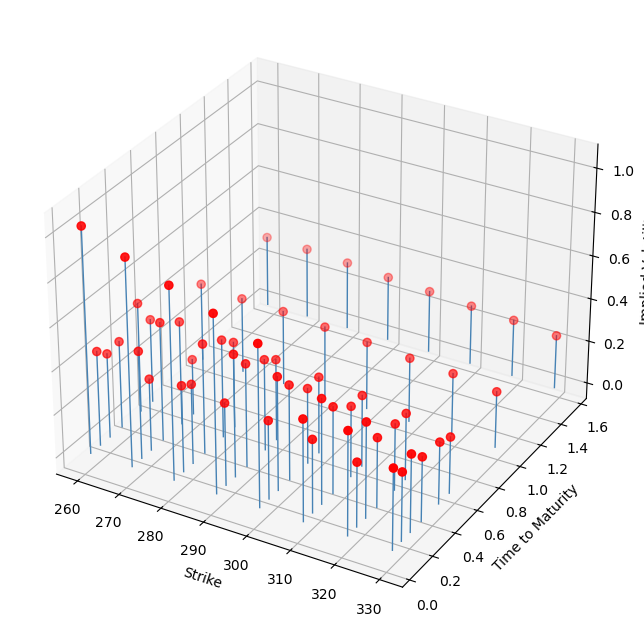

In [30]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Example data
K = df3['Strike'].copy()          # shape (N,)
T = df3['TTM'].copy()       # shape (N,)
iv = df3['IV'].copy()   # model price - market price

# Draw vertical stems
for x, y, z in zip(K, T, iv):
    ax.plot([x, x], [y, y], [0, z], color='steelblue', linewidth=1)

# Draw points
ax.scatter(K, T, iv,
           color='red',
           s=35)

ax.set_xlabel("Strike")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Implied Volatility")

plt.show()

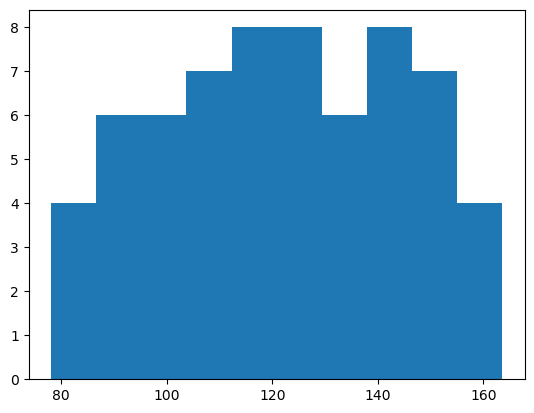

In [31]:
plt.hist(df3['Price'])
plt.show()

In [32]:
print((df3['Price'] == 0).sum())

0
